"A heartbreaking goodbye echoes through the house, but a hero's journey continues. The nation needs him. Let's pray for his safe return."

In [ ]:
# Import the necessary libraries
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os

In [ ]:
def print_classification_report(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=["Good", "Bad"],
                                   zero_division=1)
    # Print the classification report
    print(report)


def visualize_confusion_matrix(confusion_matrix):
    # Visualize the confusion matrix
    plt.figure(figsize=(4, 4))
    sns.set(font_scale=0.9)
    sns.heatmap(confusion_matrix, annot=True, fmt='d',
                cmap='Blues', cbar=False,
                xticklabels=['Good', 'Bad'],
                yticklabels=['Good', 'Bad'])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

def print_classification_report_v1(confusion_matrix):
    # Extract the values from the confusion matrix
    tp, fn, fp, tn = confusion_matrix.ravel()
    print(f"\ttp: {tp}, fn: {fn}, fp: {fp}, tn: {tn}\n")

    # Create true labels and predicted labels
    true_labels = [0] * (tp + fn) + [1] * (fp + tn)
    predicted_labels = ([0]*tp)+([1]*fn)+([0]*fp)+([1]*tn)

    label_map = {'Bad':0, 'Good':1}
    class_labels = list(label_map.keys())

    unique_class_labels = list(set(true_labels) | set(predicted_labels))

    # Create a target_names list based on the unique class labels
    new_class_labels = [k for k, v in label_map.items() if v in unique_class_labels]

    # Convert true labels and predictions to class names
    true_class_names = [class_labels[i] for i in true_labels]
    predicted_class_names = [class_labels[i] for i in predicted_labels]

    # cm = confusion_matrix(true_class_names, predicted_class_names,
    #                       labels=new_class_labels)

    # Generate the classification report
    report = classification_report(true_labels, predicted_labels,
                                   target_names=new_class_labels,
                                   zero_division=1)

    # Print the classification report
    print(report)

Data Collection Workflow Testing results

In [ ]:
folder = '/content/drive/MyDrive/Sowmya /New app testing data/'
# filename = 'v12 app testing data on july 16 with current model.csv'
filename = 'v12 app testing data on july 16 with current model 0.8th.csv'

# filename = 'v12 data collection data june10 to july 14.csv'
# filename = 'v12 data collection data june10 to july 14 with 0.7th current model.csv'
# filename = 'test_entire_app_testing_data_till_may14_with_karthik_model_in_the_app.csv'
filepath1 = os.path.join(folder, filename)

In [ ]:
df1 = pd.read_csv(filepath1)

In [ ]:
k1=df1

In [ ]:
k1

,filename,pred,reason,actual,Date
0,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
1,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
2,2024-07-30_09:56:55_(13905)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
3,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
4,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
5,2024-07-30_09:57:24_(13906)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
6,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30
7,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Good,NaN,Good,2024-07-30
8,2024-07-30_09:57:45_(13907)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30
9,2024-07-30_09:58:06_(13908)_sardine_input.jpeg,Bad,Soft,Good,2024-07-30


In [ ]:
k1['reason'].value_counts()

,count
reason,
Soft,16
Size,3
Cuts,2


In [ ]:
# k1[(k1['reason']=='Size')&(k1['actual']=='Bad')]

In [ ]:
c1 = k1['actual']=='Good'
c2 = k1['pred']=='Good'
c3 = k1['actual']=='Bad'
c4 = k1['pred']=='Bad'

In [ ]:
tp = k1[c1&c2].shape[0]
fn = k1[c1&c4].shape[0]
fp = k1[c3&c2].shape[0]
tn = k1[c3&c4].shape[0]

	tp: 22, fn: 21, fp: 0, tn: 0

              precision    recall  f1-score   support

         Bad       1.00      0.51      0.68        43
        Good       0.00      1.00      0.00         0

    accuracy                           0.51        43
   macro avg       0.50      0.76      0.34        43
weighted avg       1.00      0.51      0.68        43



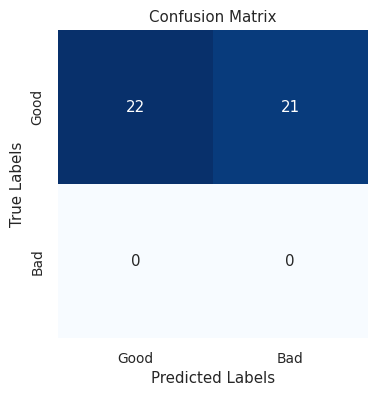

In [ ]:
# confusion matrix
cm1 = np.array([[tp, fn], [fp, tn]])
# cm1 = np.array([[12, 34], [116, 39]])
print_classification_report_v1(cm1)
visualize_confusion_matrix(cm1)

	tp: 21, fn: 22, fp: 0, tn: 0

              precision    recall  f1-score   support

        Good       1.00      0.49      0.66        43
         Bad       0.00      1.00      0.00         0

    accuracy                           0.49        43
   macro avg       0.50      0.74      0.33        43
weighted avg       1.00      0.49      0.66        43



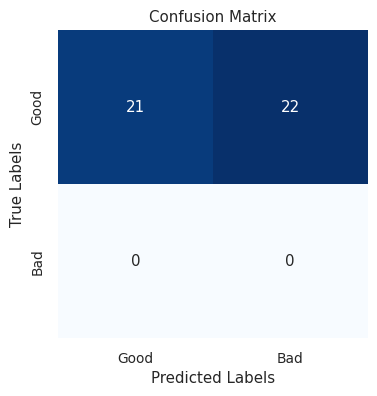

In [ ]:
# confusion matrix
cm1 = np.array([[tp, fn], [fp, tn]])
print_classification_report(cm1)
visualize_confusion_matrix(cm1)

In [ ]:
tn_df = k1[c3&c4]
tn_df

,filename,pred,reason,actual,Date
3,2024-06-11_09:44:14_(13476)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11
4,2024-06-11_09:44:14_(13476)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11
7,2024-06-11_09:44:33_(13477)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11
8,2024-06-11_09:44:33_(13477)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11
9,2024-06-11_09:44:55_(13478)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11
...,...,...,...,...,...
138,2024-06-11_09:59:28_(13521)_sardine_input.jpeg,Bad,Soft,Bad,2024-06-11
139,2024-06-11_09:59:28_(13521)_sardine_input.jpeg,Bad,Soft,Bad,2024-06-11
140,2024-06-11_09:59:28_(13521)_sardine_input.jpeg,Bad,Soft,Bad,2024-06-11
141,2024-06-11_10:00:58_(13522)_sardine_input.jpeg,Bad,Size,Bad,2024-06-11


In [ ]:
tn_df['reason'].value_counts()

reason
Size    52
Cuts    22
Soft    20
Name: count, dtype: int64

In [ ]:
tp_df = k1[c3&c2]
tp_df

,filename,pred,reason,actual,Date
0,2024-06-11_09:43:52_(13475)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
1,2024-06-11_09:43:52_(13475)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
2,2024-06-11_09:43:52_(13475)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
3,2024-06-11_09:44:14_(13476)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
4,2024-06-11_09:44:14_(13476)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
...,...,...,...,...,...
139,2024-06-11_09:59:28_(13521)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
140,2024-06-11_09:59:28_(13521)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
141,2024-06-11_10:00:58_(13522)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11
142,2024-06-11_10:00:58_(13522)_sardine_input.jpeg,Good,NaN,Bad,2024-06-11


In [ ]:
tp_df.dtypes

filename    object
pred        object
reason      object
actual      object
Date        object
dtype: object

In [ ]:
tp_df['Date'].value_counts()

Date
2024-06-11    104
Name: count, dtype: int64

In [ ]:
tp_df[(tp_df['Date']==20240502)&(tp_df['filename']=='20240502101604319_sardine_bad.jpeg')]

,filename,pred,reason,actual,Date
651,20240502101604319_sardine_bad.jpeg,Good,NaN,Bad,20240502


In [ ]:
folder = '/content/drive/MyDrive/Sowmya /New app testing data/'
filename = 'testresultsof_data_collected_from_april_18_till_may23_with_0.7th_current_model_in_the_app.csv'
# filename = 'test_entire_app_testing_data_till_may14_with_karthik_model_in_the_app.csv'
filepath2 = os.path.join(folder, filename)

In [ ]:
df2 = pd.read_csv(filepath2)

In [ ]:
k2=df2

In [ ]:
c1 = k2['actual']=='Good'
c2 = k2['pred']=='Good'
c3 = k2['actual']=='Bad'
c4 = k2['pred']=='Bad'

In [ ]:
tp = k2[c1&c2].shape[0]
fn = k2[c1&c4].shape[0]
fp = k2[c3&c2].shape[0]
tn = k2[c3&c4].shape[0]

	tp: 64, fn: 23, fp: 755, tn: 555

              precision    recall  f1-score   support

        Good       0.08      0.74      0.14        87
         Bad       0.96      0.42      0.59      1310

    accuracy                           0.44      1397
   macro avg       0.52      0.58      0.36      1397
weighted avg       0.91      0.44      0.56      1397



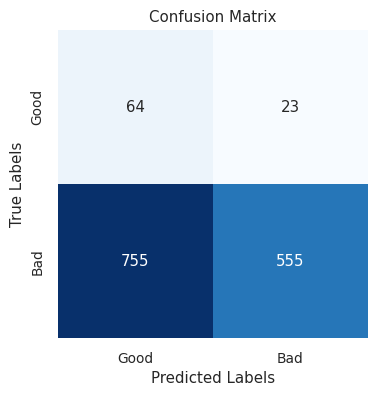

In [ ]:
# confusion matrix
cm2 = np.array([[tp, fn], [fp, tn]])
print_classification_report(cm2)
visualize_confusion_matrix(cm2)

In [ ]:
tn_df2 = k2[c3&c4]
tn_df2

,filename,pred,reason,actual,Date
3,20240423092012358_sardine_bad.jpeg,Bad,Soft,Bad,20240423
11,20240423092159655_sardine_bad.jpeg,Bad,Cuts,Bad,20240423
13,20240423092208702_sardine_bad.jpeg,Bad,Size,Bad,20240423
16,20240423092238291_sardine_bad.jpeg,Bad,Soft,Bad,20240423
17,20240423092249509_sardine_bad.jpeg,Bad,Soft,Bad,20240423
...,...,...,...,...,...
1394,20240518094855255_sardine_bad.jpeg,Bad,Cuts,Bad,20240518
1396,20240518094951085_sardine_bad.jpeg,Bad,Cuts,Bad,20240518
1397,20240518095014267_sardine_bad.jpeg,Bad,Soft,Bad,20240518
1398,20240518095024816_sardine_bad.jpeg,Bad,Soft,Bad,20240518


In [ ]:
tn_df2['reason'].value_counts()

reason
Soft    234
Cuts    197
Size    124
Name: count, dtype: int64

In [ ]:
124-112

12

In [ ]:
555-546

9

In [ ]:
tp_df2 = k2[c3&c2]
tp_df2

,filename,pred,reason,actual,Date
0,20240423091819339_sardine_bad.jpeg,Good,NaN,Bad,20240423
1,20240423091952403_sardine_bad.jpeg,Good,NaN,Bad,20240423
2,20240423092002646_sardine_bad.jpeg,Good,NaN,Bad,20240423
4,20240423092024373_sardine_bad.jpeg,Good,NaN,Bad,20240423
5,20240423092034546_sardine_bad.jpeg,Good,NaN,Bad,20240423
...,...,...,...,...,...
1385,20240518094353927_sardine_bad.jpeg,Good,NaN,Bad,20240518
1389,20240518094631822_sardine_bad.jpeg,Good,NaN,Bad,20240518
1392,20240518094832975_sardine_bad.jpeg,Good,NaN,Bad,20240518
1393,20240518094847964_sardine_bad.jpeg,Good,NaN,Bad,20240518


App testing data workflow testing results

In [ ]:
folder = '/content/drive/MyDrive/Sowmya /New app testing data/'
filename = 'test_entire_app_testing_data_till_may14_with_current_model_in_the_app.csv'
filepath1 = os.path.join(folder, filename)
filename = 'test_entire_app_testing_data_till_may14_with_karthik_model_in_the_app.csv'
filepath2 = os.path.join(folder, filename)

In [ ]:
df1 = pd.read_csv(filepath1)
df2 = pd.read_csv(filepath2)

In [ ]:
df1.shape, df2.shape

((3455, 4), (3535, 5))

In [ ]:
df1['reason'].value_counts()

reason
Soft    384
Cuts    205
Name: count, dtype: int64

In [ ]:
k1 = df1[df1['reason']!='Cuts']
k2 = df2[df2['Date'].isin(k1['Date'])]
k2 = k2[k2['reason']!='Cuts']

In [ ]:
k1.shape, k2.shape

((3250, 5), (3250, 5))

In [ ]:
acc1 = k1[k1['actual']==k1['pred']].shape[0]/k1.shape[0]*100
acc2 = k2[k2['actual']==k2['pred']].shape[0]/k2.shape[0]*100
print(acc1, acc2)

65.47692307692307 51.38461538461539


In [ ]:
k1['actual'].value_counts(), k1['pred'].value_counts()

(actual
 Good    2034
 Bad     1216
 Name: count, dtype: int64,
 pred
 Good    2866
 Bad      384
 Name: count, dtype: int64)

In [ ]:
c1 = k1['actual']=='Good'
c2 = k1['pred']=='Good'
c3 = k1['actual']=='Bad'
c4 = k1['pred']=='Bad'

In [ ]:
tp = k1[c1&c2].shape[0]
fn = k1[c1&c4].shape[0]
fp = k1[c3&c2].shape[0]
tn = k1[c3&c4].shape[0]

	tp: 1889, fn: 145, fp: 977, tn: 239

              precision    recall  f1-score   support

        Good       0.66      0.93      0.77      2034
         Bad       0.62      0.20      0.30      1216

    accuracy                           0.65      3250
   macro avg       0.64      0.56      0.53      3250
weighted avg       0.65      0.65      0.59      3250



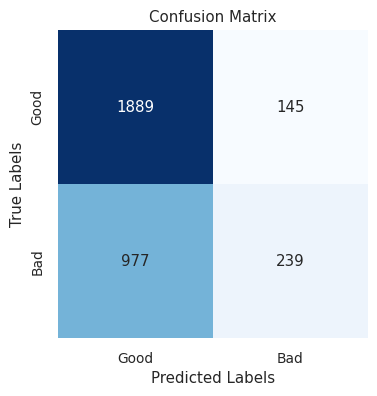

In [ ]:
# confusion matrix
cm1 = np.array([[tp, fn], [fp, tn]])
print_classification_report(cm1)
visualize_confusion_matrix(cm1)

In [ ]:
k2['actual'].value_counts(), k2['pred'].value_counts()

(actual
 Good    2034
 Bad     1216
 Name: count, dtype: int64,
 pred
 Bad     2490
 Good     760
 Name: count, dtype: int64)

In [ ]:
c1 = k2['actual']=='Good'
c2 = k2['pred']=='Good'
c3 = k2['actual']=='Bad'
c4 = k2['pred']=='Bad'

In [ ]:
tp = k2[c1&c2].shape[0]
fn = k2[c1&c4].shape[0]
fp = k2[c3&c2].shape[0]
tn = k2[c3&c4].shape[0]

	tp: 607, fn: 1427, fp: 153, tn: 1063

              precision    recall  f1-score   support

        Good       0.80      0.30      0.43      2034
         Bad       0.43      0.87      0.57      1216

    accuracy                           0.51      3250
   macro avg       0.61      0.59      0.50      3250
weighted avg       0.66      0.51      0.49      3250



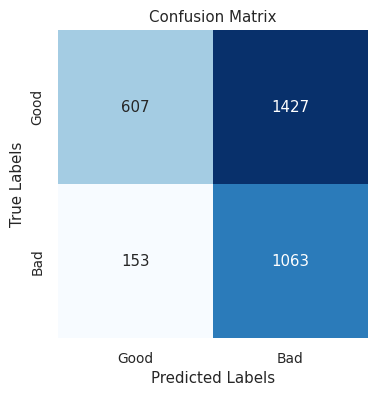

In [ ]:
# confusion matrix
cm2 = np.array([[tp, fn], [fp, tn]])
print_classification_report(cm2)
visualize_confusion_matrix(cm2)